<a href="https://colab.research.google.com/github/AliSalimkhani/DeepNN_Course2025/blob/main/Mini_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!apt-get update
!apt-get install -y build-essential cmake
!pip install ninja
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e .

Looking in indexes: https://download.pytorch.org/whl/cu118
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,204 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,543 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit

KeyboardInterrupt: 

In [ ]:
!ls

assets		    docker-compose.yaml  pyproject.toml    setup.py
backend.Dockerfile  INSTALL.md		 README.md	   tools
checkpoints	    LICENSE		 RELEASE_NOTES.md  training
CODE_OF_CONDUCT.md  LICENSE_cctorch	 sam2
CONTRIBUTING.md     MANIFEST.in		 SAM_2.egg-info
demo		    notebooks		 sav_dataset


In [ ]:

%cd checkpoints
! ./download_ckpts.sh

/content/sam2/checkpoints
--2025-12-12 04:10:50--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.96, 3.163.189.108, 3.163.189.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156008466 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_tiny.pt’

sam2.1_hiera_tiny.p 100%[===================>] 148.78M   268MB/s    in 0.6s    

2025-12-12 04:10:51 (268 MB/s) - ‘sam2.1_hiera_tiny.pt’ saved [156008466/156008466]

--2025-12-12 04:10:51--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.96, 3.163.189.108, 3.163.189.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length

In [ ]:
!pip install sam2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 6.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.8 MB/s eta 0:00:00
  Created wheel for sam2: filename=sam2-1.1.0-cp312-cp312-linux_x86_64.whl size=501942 sha256=361ac79b3a3d0bdf2a3ef1f8d0188bb1f83a27836179b43c1b688c452053a524
  Stored in directory: /root/.cache/pip/wheels/22/cb/54/0351e695a7a2e8eed8d5987cd02d8e5227eec87b0bbcc00094
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=9363b8cba37d8cad4edc294610e333b39c36ce1a8ef48261150796471ee7d264
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built sam2 iopath


In [ ]:
%cd ../../../../../content
!ls

/content
sam2
sample_data
stock-footage-cookies-on-a-conveyor-in-a-confectionery-factory-oven-freshly-baked-shortbread-cookies-leave-the.mp4


In [ ]:
import cv2
import os

os.makedirs("frames", exist_ok=True)

cap = cv2.VideoCapture("output_video_with_detections (1).mp4")
frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(f"frames/frame_{frame_id:04d}.jpg", frame)
    frame_id += 1

cap.release()

print("Extracted frames:", frame_id)


Extracted frames: 244



0: 384x640 14 umbrellas, 2 frisbees, 14 surfboards, 9.8ms
Speed: 1.9ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


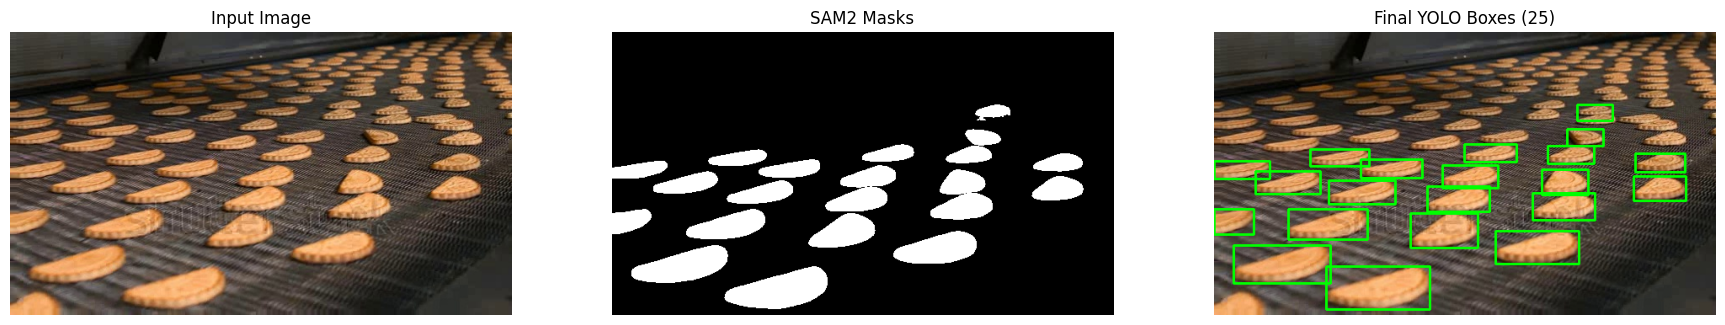

Done. 25 objects saved to YOLO.


In [ ]:
import torch
import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sam2.sam2_image_predictor import SAM2ImagePredictor


frame_path = "/content/frames/frame_0001.jpg"
label_path = "/content/labels/frame_0001.txt"
os.makedirs("/content/labels", exist_ok=True)


device = "cuda" if torch.cuda.is_available() else "cpu"

weak_yolo = YOLO("yolov8n.pt")
sam = SAM2ImagePredictor.from_pretrained(
    "facebook/sam2-hiera-large"
)

img = Image.open(frame_path).convert("RGB")
img_np = np.array(img)
h_img, w_img, _ = img_np.shape


results = weak_yolo(
    img_np,
    conf=0.05,
    iou=0.5,
    max_det=1000
)[0]

boxes = results.boxes.xyxy.cpu().numpy()
scores = results.boxes.conf.cpu().numpy()

sam.set_image(img_np)

yolo_lines = []
img_vis = img_np.copy()
sam_vis = np.zeros((h_img, w_img), dtype=np.uint8)


for (x1, y1, x2, y2), score in zip(boxes, scores):

    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    if (x2 - x1) < 20 or (y2 - y1) < 20:
        continue


    shrink = 0.9
    bw = x2 - x1
    bh = y2 - y1

    sx1 = int(x1 + (1 - shrink) * bw / 2)
    sy1 = int(y1 + (1 - shrink) * bh / 2)
    sx2 = int(x2 - (1 - shrink) * bw / 2)
    sy2 = int(y2 - (1 - shrink) * bh / 2)

    sx1 = max(0, sx1)
    sy1 = max(0, sy1)
    sx2 = min(w_img - 1, sx2)
    sy2 = min(h_img - 1, sy2)


    cx = (sx1 + sx2) // 2
    cy = (sy1 + sy2) // 2


    masks, _, _ = sam.predict(
        point_coords=np.array([[cx, cy]]),
        point_labels=np.array([1], dtype=np.int32),
        box=np.array([[sx1, sy1, sx2, sy2]]),
        multimask_output=False
    )

    mask = masks[0].astype(np.uint8) * 255
    sam_vis = np.maximum(sam_vis, mask)

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        continue

    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 100:
        continue

    xx, yy, ww, hh = cv2.boundingRect(c)


    xn = (xx + ww / 2) / w_img
    yn = (yy + hh / 2) / h_img
    wn = ww / w_img
    hn = hh / h_img

    yolo_lines.append(f"0 {xn:.6f} {yn:.6f} {wn:.6f} {hn:.6f}")


    cv2.rectangle(img_vis, (xx, yy), (xx + ww, yy + hh), (0, 255, 0), 2)

with open(label_path, "w") as f:
    f.write("\n".join(yolo_lines))

fig, axs = plt.subplots(1, 3, figsize=(22, 6))

axs[0].imshow(img_np)
axs[0].set_title("Input Image")
axs[0].axis("off")

axs[1].imshow(sam_vis, cmap="gray")
axs[1].set_title("SAM2 Masks")
axs[1].axis("off")

axs[2].imshow(img_vis)
axs[2].set_title(f"Final YOLO Boxes ({len(yolo_lines)})")
axs[2].axis("off")

plt.show()

print(f"Done. {len(yolo_lines)} objects saved to YOLO.")


In [ ]:
import torch
import cv2
import numpy as np
from PIL import Image
import os

from ultralytics import YOLO
from sam2.sam2_image_predictor import SAM2ImagePredictor

frames_dir = "/content/frames"
labels_dir = "/content/labels"
os.makedirs(labels_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading YOLO...")
weak_yolo = YOLO("yolov8n.pt")

print("Loading SAM2...")
sam = SAM2ImagePredictor.from_pretrained(
    "facebook/sam2-hiera-large"
)

CONF_TH = 0.05
IOU_TH = 0.5
MAX_DET = 1000
MIN_AREA = 100
CLASS_ID = 0

frame_files = sorted([
    f for f in os.listdir(frames_dir)
    if f.lower().endswith((".jpg", ".png"))
])

print(f"Total frames: {len(frame_files)}")

for idx, frame_name in enumerate(frame_files):
    frame_path = os.path.join(frames_dir, frame_name)
    label_path = os.path.join(
        labels_dir, frame_name.rsplit(".", 1)[0] + ".txt"
    )

    print(f"[{idx+1}/{len(frame_files)}] Processing {frame_name}")

    img = Image.open(frame_path).convert("RGB")
    img_np = np.array(img)
    h_img, w_img, _ = img_np.shape

    results = weak_yolo(
        img_np,
        conf=CONF_TH,
        iou=IOU_TH,
        max_det=MAX_DET,
        verbose=False
    )[0]

    if results.boxes is None:
        open(label_path, "w").close()
        continue

    boxes = results.boxes.xyxy.cpu().numpy()

    sam.set_image(img_np)

    yolo_lines = []

    for (x1, y1, x2, y2) in boxes:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        shrink = 0.9
        bw, bh = x2 - x1, y2 - y1

        sx1 = int(x1 + (1 - shrink) * bw / 2)
        sy1 = int(y1 + (1 - shrink) * bh / 2)
        sx2 = int(x2 - (1 - shrink) * bw / 2)
        sy2 = int(y2 - (1 - shrink) * bh / 2)

        sx1 = max(0, sx1)
        sy1 = max(0, sy1)
        sx2 = min(w_img - 1, sx2)
        sy2 = min(h_img - 1, sy2)

        cx = (sx1 + sx2) // 2
        cy = (sy1 + sy2) // 2

        masks, _, _ = sam.predict(
            point_coords=np.array([[cx, cy]]),
            point_labels=np.array([1], dtype=np.int32),
            box=np.array([[sx1, sy1, sx2, sy2]]),
            multimask_output=False
        )

        mask = masks[0].astype(np.uint8)

        cnts, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if not cnts:
            continue

        c = max(cnts, key=cv2.contourArea)
        if cv2.contourArea(c) < MIN_AREA:
            continue

        xx, yy, ww, hh = cv2.boundingRect(c)

        xn = (xx + ww / 2) / w_img
        yn = (yy + hh / 2) / h_img
        wn = ww / w_img
        hn = hh / h_img

        yolo_lines.append(
            f"{CLASS_ID} {xn:.6f} {yn:.6f} {wn:.6f} {hn:.6f}"
        )

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    print(f"  Saved {len(yolo_lines)} objects")

print("Done. All frames processed.")


Loading YOLO...
Loading SAM2...
Total frames: 244
[1/244] Processing frame_0000.jpg
  Saved 19 objects
[2/244] Processing frame_0001.jpg
  Saved 25 objects
[3/244] Processing frame_0002.jpg
  Saved 29 objects
[4/244] Processing frame_0003.jpg
  Saved 21 objects
[5/244] Processing frame_0004.jpg
  Saved 19 objects
[6/244] Processing frame_0005.jpg
  Saved 16 objects
[7/244] Processing frame_0006.jpg
  Saved 27 objects
[8/244] Processing frame_0007.jpg
  Saved 22 objects
[9/244] Processing frame_0008.jpg
  Saved 14 objects
[10/244] Processing frame_0009.jpg
  Saved 21 objects
[11/244] Processing frame_0010.jpg
  Saved 26 objects
[12/244] Processing frame_0011.jpg
  Saved 26 objects
[13/244] Processing frame_0012.jpg
  Saved 24 objects
[14/244] Processing frame_0013.jpg
  Saved 22 objects
[15/244] Processing frame_0014.jpg
  Saved 17 objects
[16/244] Processing frame_0015.jpg
  Saved 17 objects
[17/244] Processing frame_0016.jpg
  Saved 13 objects
[18/244] Processing frame_0017.jpg
  Save

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.2 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

frames_dir = "/content/frames"
labels_dir = "/content/labels"
dataset_dir = "/content/yolo_dataset"

train_images_dir = os.path.join(dataset_dir, "images/train")
val_images_dir = os.path.join(dataset_dir, "images/val")
train_labels_dir = os.path.join(dataset_dir, "labels/train")
val_labels_dir = os.path.join(dataset_dir, "labels/val")

os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(val_images_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

all_files = sorted([f for f in os.listdir(frames_dir) if f.endswith(".jpg")])
random.shuffle(all_files)

split_index = int(0.8 * len(all_files))
train_files = all_files[:split_index]
val_files = all_files[split_index:]

print("در حال کپی کردن فایل‌های آموزش...")
for filename in tqdm(train_files):

    shutil.copy(os.path.join(frames_dir, filename), os.path.join(train_images_dir, filename))

    label_filename = filename.replace(".jpg", ".txt")
    shutil.copy(os.path.join(labels_dir, label_filename), os.path.join(train_labels_dir, label_filename))

print("\nدر حال کپی کردن فایل‌های اعتبارسنجی...")
for filename in tqdm(val_files):

    shutil.copy(os.path.join(frames_dir, filename), os.path.join(val_images_dir, filename))

    label_filename = filename.replace(".jpg", ".txt")
    shutil.copy(os.path.join(labels_dir, label_filename), os.path.join(val_labels_dir, label_filename))

print(f"\nتقسیم داده‌ها تمام شد!")
print(f"تعداد فایل‌های آموزش: {len(train_files)}")
print(f"تعداد فایل‌های اعتبارسنجی: {len(val_files)}")

در حال کپی کردن فایل‌های آموزش...


100%|██████████| 195/195 [00:00<00:00, 3293.60it/s]



در حال کپی کردن فایل‌های اعتبارسنجی...


100%|██████████| 49/49 [00:00<00:00, 3339.79it/s]


تقسیم داده‌ها تمام شد!
تعداد فایل‌های آموزش: 195
تعداد فایل‌های اعتبارسنجی: 49


In [ ]:

file_path = "/content/yolo_dataset/data.yaml"

yaml_content = """
train: images/train
val: images/val

# تعداد کلاس‌ها
nc: 1

# نام کلاس‌ها (به ترتیب شماره‌گذاری)
names:
  0: cookie
"""

with open(file_path, "w") as f:
    f.write(yaml_content)

print(f"فایل YAML ساخته شد: {file_path}")


فایل YAML ساخته شد: /content/yolo_dataset/data.yaml


In [33]:
from ultralytics import YOLO


model = YOLO('yolo11n.pt')

results = model.train(
    data='/content/yolo_dataset/data.yaml',
    epochs=500,
    imgsz=640,
    batch=16,
    name='yolo11n_cookie_det',
    project='/content/runs/detect',
    device=0
)

print("آموزش مدل با موفقیت به پایان رسید!")
print(f"نتایج در مسیر زیر ذخیره شدند: {results.save_dir}")

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11n_cookie_det2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

 frames  'output_video_with_detections (1).mp4'   sample_data   yolo_dataset
 labels   runs					  yolo11n.pt    yolov8n.pt



image 1/1 /content/frames/frame_0025.jpg: 384x640 37 cookies, 20.5ms
Speed: 6.3ms preprocess, 20.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


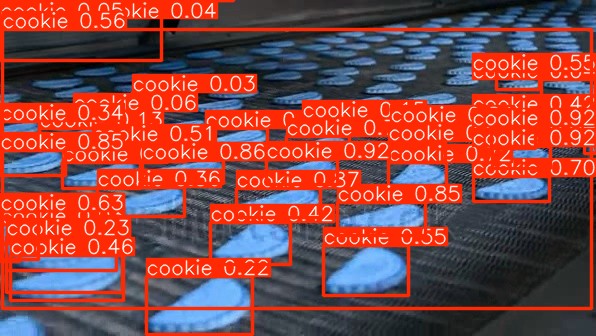

In [52]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

trained_model = YOLO('/content/runs/detect/yolo11n_cookie_det/weights/best.pt')


test_image_path = "/content/frames/frame_0025.jpg"

results = trained_model.predict(test_image_path, conf=0.02)

for r in results:
    im_array = r.plot()
    im = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
    cv2_imshow(im)

In [39]:
from ultralytics import YOLO
import cv2

# 1. بارگذاری مدل آموزش‌دیده
model = YOLO('/content/runs/detect/yolo11n_cookie_det/weights/best.pt')

# 2. تعریف مسیرهای ورودی و خروجی
input_video_path = "/content/output_video_with_detections (1).mp4" # مسیر ویدیوی شما
output_video_path = "/content/s.mp4"

# 3. راه‌اندازی خواننده ویدیو
cap = cv2.VideoCapture(input_video_path)

# دریافت اطلاعات ویدیوی ورودی (فریم ریت، ابعاد)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 4. راه‌اندازی نویسنده ویدیو برای ذخیره خروجی
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # کدک برای فایل mp4
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# 5. حلقه اصلی برای پردازش فریم‌ها
frame_count = 0
while cap.isOpened():
    success, frame = cap.read()

    if not success:
        print("پردازش ویدیو به پایان رسید.")
        break

    # اجرای تشخیص روی فریم
    results = model.predict(frame, verbose=False)

    # رسم نتایج روی فریم
    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0]
            cls = int(box.cls[0])
            class_name = model.names[cls]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f'{class_name}: {confidence:.2f}'
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # نوشتن فریم پردازش شده در فایل ویدیوی خروجی
    out.write(frame)

    frame_count += 1
    print(f"در حال پردازش فریم {frame_count}...")

# 6. آزادسازی منابع
cap.release()
out.release()

print(f"\nویدیوی خروجی با موفقیت در مسیر زیر ذخیره شد:")
print(output_video_path)

در حال پردازش فریم 1...
در حال پردازش فریم 2...
در حال پردازش فریم 3...
در حال پردازش فریم 4...
در حال پردازش فریم 5...
در حال پردازش فریم 6...
در حال پردازش فریم 7...
در حال پردازش فریم 8...
در حال پردازش فریم 9...
در حال پردازش فریم 10...
در حال پردازش فریم 11...
در حال پردازش فریم 12...
در حال پردازش فریم 13...
در حال پردازش فریم 14...
در حال پردازش فریم 15...
در حال پردازش فریم 16...
در حال پردازش فریم 17...
در حال پردازش فریم 18...
در حال پردازش فریم 19...
در حال پردازش فریم 20...
در حال پردازش فریم 21...
در حال پردازش فریم 22...
در حال پردازش فریم 23...
در حال پردازش فریم 24...
در حال پردازش فریم 25...
در حال پردازش فریم 26...
در حال پردازش فریم 27...
در حال پردازش فریم 28...
در حال پردازش فریم 29...
در حال پردازش فریم 30...
در حال پردازش فریم 31...
در حال پردازش فریم 32...
در حال پردازش فریم 33...
در حال پردازش فریم 34...
در حال پردازش فریم 35...
در حال پردازش فریم 36...
در حال پردازش فریم 37...
در حال پردازش فریم 38...
در حال پردازش فریم 39...
در حال پردازش فریم 40...
در حال پر

In [53]:
from ultralytics import YOLO
import cv2
import numpy as np
from scipy.spatial import distance as dist
from collections import OrderedDict

class CentroidTracker:
    def __init__(self, maxDisappeared=50):
        self.nextObjectID = 0
        self.objects = OrderedDict()
        self.disappeared = OrderedDict()
        self.maxDisappeared = maxDisappeared

    def register(self, centroid):
        self.objects[self.nextObjectID] = centroid
        self.disappeared[self.nextObjectID] = 0
        self.nextObjectID += 1

    def deregister(self, objectID):
        del self.objects[objectID]
        del self.disappeared[objectID]

    def update(self, rects):
        if len(rects) == 0:
            for objectID in list(self.disappeared.keys()):
                self.disappeared[objectID] += 1
                if self.disappeared[objectID] > self.maxDisappeared:
                    self.deregister(objectID)
            return self.objects

        inputCentroids = np.zeros((len(rects), 2), dtype="int")
        for (i, (startX, startY, endX, endY)) in enumerate(rects):
            cX = int((startX + endX) / 2.0)
            cY = int((startY + endY) / 2.0)
            inputCentroids[i] = (cX, cY)

        if len(self.objects) == 0:
            for i in range(len(inputCentroids)):
                self.register(inputCentroids[i])
        else:
            objectIDs = list(self.objects.keys())
            objectCentroids = list(self.objects.values())

            D = dist.cdist(np.array(objectCentroids), inputCentroids)
            rows = D.min(axis=1).argsort()
            cols = D.argmin(axis=1)[rows]

            usedRows = set()
            usedCols = set()

            for (row, col) in zip(rows, cols):
                if row in usedRows or col in usedCols:
                    continue
                objectID = objectIDs[row]
                self.objects[objectID] = inputCentroids[col]
                self.disappeared[objectID] = 0
                usedRows.add(row)
                usedCols.add(col)

            unusedRows = set(range(0, D.shape[0])).difference(usedRows)
            unusedCols = set(range(0, D.shape[1])).difference(usedCols)

            if D.shape[0] >= D.shape[1]:
                for row in unusedRows:
                    objectID = objectIDs[row]
                    self.disappeared[objectID] += 1
                    if self.disappeared[objectID] > self.maxDisappeared:
                        self.deregister(objectID)
            else:
                for col in unusedCols:
                    self.register(inputCentroids[col])

        return self.objects

model = YOLO('/content/runs/detect/yolo11n_cookie_det/weights/best.pt')

input_video_path = "/content/output_video_with_detections (1).mp4"
output_video_path = "/content/output_video_with_counting.mp4"

cap = cv2.VideoCapture(input_video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

COUNT_LINE_Y = height // 2
line_start_point = (0, COUNT_LINE_Y)
line_end_point = (width, COUNT_LINE_Y)

ct = CentroidTracker(maxDisappeared=20)
object_count = 0
counted_objects = set()

print("شروع پردازش ویدیو برای شمارش اشیاء...")

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("پردازش ویدیو به پایان رسید.")
        break

    results = model.predict(frame, verbose=False)
    rects = []

    for r in results:
        boxes = r.boxes
        for box in boxes:
            cls = int(box.cls[0])
            if model.names[cls] == 'cookie':
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                width_bb = x2 - x1
                height_bb = y2 - y1

                if width_bb > 100 or height_bb > 100 or width_bb < 20 or height_bb < 20:
                    continue

                rects.append((x1, y1, x2, y2))

    objects = ct.update(rects)

    for (objectID, centroid) in objects.items():
        for (x1, y1, x2, y2) in rects:
            cX = (x1 + x2) // 2
            cY = (y1 + y2) // 2
            if abs(cX - centroid[0]) < 20 and abs(cY - centroid[1]) < 20:
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"ID {objectID}", (centroid[0] - 10, centroid[1] - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                break

        if objectID not in counted_objects:
            if centroid[1] > COUNT_LINE_Y:
                object_count += 1
                counted_objects.add(objectID)
                print(f"فریم {frame_count}: شیء با ID {objectID} عبور کرد. تعداد کل: {object_count}")

    cv2.line(frame, line_start_point, line_end_point, (0, 0, 255), 2)
    cv2.putText(frame, f"Count: {object_count}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    out.write(frame)
    frame_count += 1

cap.release()
out.release()
print(f"\nپردازش تمام شد.")
print(f"ویدیوی خروجی با موفقیت در مسیر زیر ذخیره شد:")
print(output_video_path)


شروع پردازش ویدیو برای شمارش اشیاء...
فریم 0: شیء با ID 0 عبور کرد. تعداد کل: 1
فریم 0: شیء با ID 1 عبور کرد. تعداد کل: 2
فریم 0: شیء با ID 3 عبور کرد. تعداد کل: 3
فریم 0: شیء با ID 4 عبور کرد. تعداد کل: 4
فریم 0: شیء با ID 5 عبور کرد. تعداد کل: 5
فریم 0: شیء با ID 7 عبور کرد. تعداد کل: 6
فریم 0: شیء با ID 8 عبور کرد. تعداد کل: 7
فریم 0: شیء با ID 11 عبور کرد. تعداد کل: 8
فریم 0: شیء با ID 12 عبور کرد. تعداد کل: 9
فریم 0: شیء با ID 13 عبور کرد. تعداد کل: 10
فریم 2: شیء با ID 18 عبور کرد. تعداد کل: 11
فریم 8: شیء با ID 14 عبور کرد. تعداد کل: 12
فریم 18: شیء با ID 20 عبور کرد. تعداد کل: 13
فریم 18: شیء با ID 21 عبور کرد. تعداد کل: 14
فریم 18: شیء با ID 22 عبور کرد. تعداد کل: 15
فریم 18: شیء با ID 23 عبور کرد. تعداد کل: 16
فریم 18: شیء با ID 24 عبور کرد. تعداد کل: 17
فریم 18: شیء با ID 25 عبور کرد. تعداد کل: 18
فریم 18: شیء با ID 26 عبور کرد. تعداد کل: 19
فریم 18: شیء با ID 27 عبور کرد. تعداد کل: 20
فریم 57: شیء با ID 29 عبور کرد. تعداد کل: 21
فریم 57: شیء با ID 30 عبور کرد. تعداد کل: 22
